# Enrichment of Multimodal axon guidance in Human Data

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
import scanpy as sc
import numpy as np
import gseapy as gp
from gseapy import barplot, dotplot, heatmap
from gseapy.plot import gseaplot
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
import requests
from bs4 import BeautifulSoup
import re
import csv

In [2]:
""" Load Datasets """

# Load the counts and meta file for the dataset of interest
#For this project we used data obtained from Peng et al. and Chen et al.

dataDir='/...'
OutDir = '/...'

#adata = pd.read_csv(filename...) 
#adata.obs = meta

""" State the cluster name """
clust_sel = ''

In [3]:
grouplist = ['myCAF','iCAF']

grouplist.sort()

df = pd.DataFrame()
for i in grouplist:
    sc.tl.rank_genes_groups(adata, clust_sel, groups=[i],  method='t-test', reference='rest',
                            use_raw=True, key_added= i)  
    result = adata.uns[i]
        
    # create a dictionary
    lfc_dict = dict()
    for x in result['names'].dtype.names:
        lfc_dict[x] = dict(zip(result['names'][x],result['scores'][x]))
        
        
    df2 = pd.DataFrame(lfc_dict)
    df = pd.concat([df,df2], axis=1)

/home/hinds/anaconda3/envs/gsea/lib/python3.10/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


In [4]:

axon_pathways_gene_sets = {'Multimodal Axon Guidance and Neurotrophic Signaling': [
    'AGRN', 'ARTN', 'BDNF', 'COL3A1', 'COL4A1', 'COL4A2', 'COL4A3', 'COL4A4', 'COL5A1', 'COL5A2', 'COL5A3', 'COL6A1', 
    'COL6A2', 'COL6A3', 'COL6A5', 'COL6A6', 'COL9A1', 'COL9A2', 'COL9A3', 'CXCL12', 'DRAXIN', 'EFNA1', 'EFNA2', 'EFNA3', 
    'EFNA4', 'EFNA5', 'EFNB1', 'EFNB2', 'EFNB3', 'FN1', 'GDNF', 'GFRA1', 'GFRA2', 'GFRA3', 'GFRA4', 'GPC1', 'L1CAM', 
    'LAMA1', 'LAMB1', 'LAMC1', 'MMP2', 'MMP9', 'NCAM1', 'NEO1', 'NGF', 'NRCAM', 'NREP', 'NRTN', 'NTF3', 'NTN1', 
    'NTN4', 'NRP1', 'NRP2', 'PLXNA1', 'PLXNA2', 'PLXNA3', 'PLXNA4', 'PLXNB1', 'PLXNB2', 'PLXNB3', 'PLXNB4', 'PLXNC1', 
    'PLXND1', 'PLEXNB3', 'PSPN', 'RGMA', 'ROBO1', 'ROBO2', 'ROBO3', 'ROBO4', 'SEMA3A', 'SEMA3E', 'SEMA3F', 'SEMA4A', 
    'SEMA4D', 'SEMA5A', 'SEMA6A', 'SEMA6D', 'SEMA7A', 'SLIT1', 'SLIT2', 'SLIT3', 'TGFB1', 'TNC', 'EPHA1', 'EPHA3', 
    'EPHA4', 'EPHA5', 'EPHA10', 'EPHB1', 'EPHB2', 'EPHB4', 'UNC5A', 'UNC5C', 'UNC5D'
]}

In [5]:
# Table showing expression levels of genes in data

import scipy.sparse as sp

# pick the gene list
genes = axon_pathways_gene_sets['Multimodal Axon Guidance and Neurotrophic Signaling']
genes_present = [g for g in genes if g in adata.var_names]

X = adata[:, genes_present].X

if sp.issparse(X):
    pct_expressed = np.array((X > 0).sum(axis=0) / X.shape[0]).flatten() * 100
    mean_expr = np.array(X.mean(axis=0)).flatten()
else:
    pct_expressed = (X > 0).mean(axis=0) * 100
    mean_expr = X.mean(axis=0)

expr_summary = pd.DataFrame({
    'Gene': genes_present,
    '%_Expressing_Cells': pct_expressed,
    'Mean_Expression': mean_expr
})

# sort (optional)
#expr_summary = expr_summary.sort_values(by='%_Expressing_Cells', ascending=False).reset_index(drop=True)
#expr_summary.to_csv(OutDir+ "Expression_levels_of_axon_guidance_genes_in_Zhang_Dataset.csv",sep='\t')

In [6]:
# Add an adenment that the gene has to present in

def filter_gene_sets(adata, gene_sets, min_pct=0.10):
    filtered = {}
    for name, genes in gene_sets.items():
        valid_genes = [g for g in genes if g in adata.var_names]
        if len(valid_genes) == 0:
            continue  # skip if none are found

        # Calculate % of cells expressing each gene
        expr = np.asarray((adata[:, valid_genes].X > 0).mean(axis=0)).flatten()
        filtered_genes = [g for g, pct in zip(valid_genes, expr) if pct >= min_pct]

        filtered[name] = filtered_genes
    return filtered

axon_pathways_gene_sets = filter_gene_sets(adata, axon_pathways_gene_sets,min_pct=0.10)

2025-11-14 20:10:50,048 [WARNING] Duplicated values found in preranked stats: 38.86% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 20:10:50,049 [INFO] Parsing data files for GSEA.............................
2025-11-14 20:10:50,051 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 20:10:50,052 [INFO] 0001 gene_sets used for further statistical testing.....
2025-11-14 20:10:50,052 [INFO] Start to run GSEA...Might take a while..................
2025-11-14 20:10:51,209 [INFO] Congratulations. GSEApy runs successfully................



iCAF


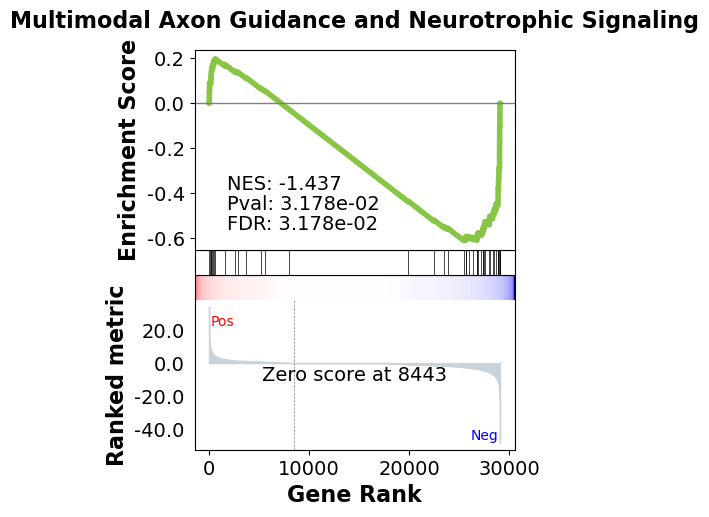

2025-11-14 20:10:51,521 [WARNING] Duplicated values found in preranked stats: 38.86% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-14 20:10:51,521 [INFO] Parsing data files for GSEA.............................
2025-11-14 20:10:51,524 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2025-11-14 20:10:51,525 [INFO] 0001 gene_sets used for further statistical testing.....
2025-11-14 20:10:51,525 [INFO] Start to run GSEA...Might take a while..................
2025-11-14 20:10:52,697 [INFO] Congratulations. GSEApy runs successfully................



myCAF


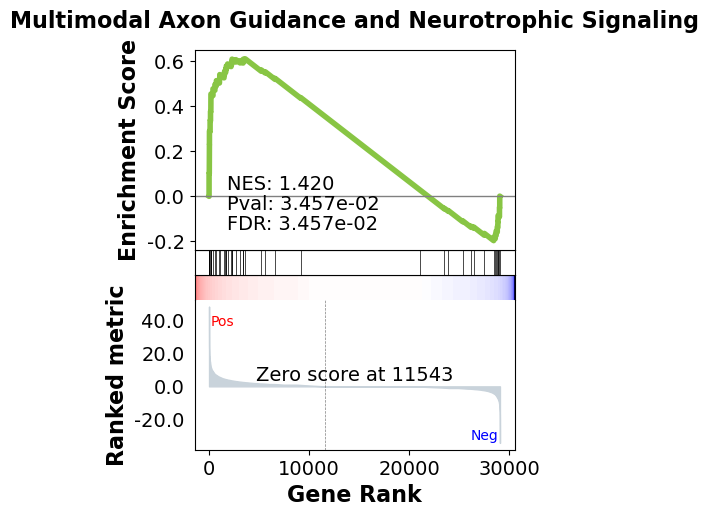

In [7]:
for a in grouplist:
    ranking = df[[a]].copy() 
    
    ranking.sort_values(by=a, ascending=False, inplace=True)
    ranking.reset_index(drop=False, inplace=True)
    ranking.rename(columns={"index": "Gene", a: "score"}, inplace=True)
    
    pre_res = gp.prerank(
        rnk=ranking, 
        gene_sets=axon_pathways_gene_sets,
        threads=4,
        min_size=5,
        max_size=1000,
        permutation_num=1000,
        outdir=None,
        seed=6,
        verbose=True,
    )
    
    table = pre_res.res2d
    terms = pre_res.res2d.Term
    
    # Adjusting the code for teh enrichment plot

    axs = pre_res.plot(terms=terms[0])
    fig = plt.gcf()
    fig.patch.set_alpha(0.0)
    #main_ax = axs
     
    #Bottom  panel ---
    axs = fig.axes 
    metric_ax = axs[0] 

    metric_ax.set_facecolor('none')
    fig.patch.set_alpha(0.0)

    for txt in metric_ax.texts:
        if "Zero score at" in txt.get_text():
            y = txt.get_position()[1]
            txt.set_x(0.5)  
            txt.set_horizontalalignment('center')
            txt.set_verticalalignment('center')
            txt.set_transform(metric_ax.transAxes) 
    print(a)
    plt.show()    
    out_file = f"{OutDir}{a}_Cheng_enrichment_plot.png"
    #fig.savefig(out_file, dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.1)
    #plt.close(fig)
